# 02 - MNIST Model Training & Visualization

This notebook trains a neural network on MNIST data loaded from DuckDB, then visualizes:
- Training loss & accuracy curves
- Confusion matrix
- Per-digit accuracy
- Misclassified examples

**Key ML Concepts Covered:**
- Neural network architecture (layers, activations)
- Forward/backward propagation
- Loss functions & optimizers
- Batch training with DataLoaders
- Overfitting detection (train vs validation)

In [1]:
import numpy as np
import duckdb
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from pathlib import Path
from tqdm.notebook import tqdm

## 1. Load Data from DuckDB

In [2]:
con = duckdb.connect(str(Path('../data/mnist.duckdb')), read_only=True)

train_data = con.execute("SELECT * FROM mnist WHERE split='train'").fetchnumpy()
test_data = con.execute("SELECT * FROM mnist WHERE split='test'").fetchnumpy()
con.close()

# Extract pixel columns and labels
px_cols = [f'px{i}' for i in range(784)]
X_train = np.column_stack([train_data[c] for c in px_cols]).astype(np.float32) / 255.0
y_train = train_data['label'].astype(np.int64)
X_test = np.column_stack([test_data[c] for c in px_cols]).astype(np.float32) / 255.0
y_test = test_data['label'].astype(np.int64)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (60000, 784), Test: (10000, 784)


## 2. Create PyTorch DataLoaders

DataLoaders handle batching and shuffling. Batch size is a key hyperparameter:
- **Smaller batches** → noisier gradients, can help escape local minima
- **Larger batches** → smoother gradients, faster training per epoch

In [ ]:
BATCH_SIZE = 32

train_ds = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
test_ds = TensorDataset(torch.tensor(X_test), torch.tensor(y_test))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

## 3. Define the Neural Network

Architecture: 784 → 256 → 128 → 10

**Key parameters to experiment with:**
- Hidden layer sizes (try 64, 128, 256, 512)
- Number of layers (try 1-4 hidden layers)
- Activation function (ReLU, Sigmoid, Tanh)
- Dropout rate (regularization to prevent overfitting)

In [4]:
class MNISTNet(nn.Module):
    def __init__(self, hidden1=256, hidden2=128, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, 10)
        )

    def forward(self, x):
        return self.net(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## 4. Training Loop

**Hyperparameters:**
- `lr` (learning rate): How big each optimization step is. Too high → diverges. Too low → slow.
- `epochs`: Number of full passes through the training data.
- `optimizer`: Adam adapts learning rate per-parameter. SGD is simpler but needs tuning.

In [5]:
# === HYPERPARAMETERS (experiment with these!) ===
EPOCHS = 15
LEARNING_RATE = 1e-3
HIDDEN1 = 256
HIDDEN2 = 128
DROPOUT = 0.2

model = MNISTNet(HIDDEN1, HIDDEN2, DROPOUT).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f'Model parameters: {sum(p.numel() for p in model.parameters()):,}')
print(model)

Model parameters: 235,146
MNISTNet(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [6]:
# Training with metrics tracking
history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

for epoch in tqdm(range(EPOCHS), desc='Training'):
    # Train
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * len(y_batch)
        correct += (outputs.argmax(1) == y_batch).sum().item()
        total += len(y_batch)
    history['train_loss'].append(running_loss / total)
    history['train_acc'].append(correct / total)

    # Evaluate
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            running_loss += loss.item() * len(y_batch)
            correct += (outputs.argmax(1) == y_batch).sum().item()
            total += len(y_batch)
    history['test_loss'].append(running_loss / total)
    history['test_acc'].append(correct / total)

    print(f"Epoch {epoch+1:2d} | Train Loss: {history['train_loss'][-1]:.4f} Acc: {history['train_acc'][-1]:.4f} | "
          f"Test Loss: {history['test_loss'][-1]:.4f} Acc: {history['test_acc'][-1]:.4f}")

Training:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch  1 | Train Loss: 0.3803 Acc: 0.8898 | Test Loss: 0.1511 Acc: 0.9547
Epoch  2 | Train Loss: 0.1498 Acc: 0.9547 | Test Loss: 0.1011 Acc: 0.9693
Epoch  3 | Train Loss: 0.1079 Acc: 0.9671 | Test Loss: 0.0837 Acc: 0.9731
Epoch  4 | Train Loss: 0.0836 Acc: 0.9739 | Test Loss: 0.0759 Acc: 0.9762
Epoch  5 | Train Loss: 0.0703 Acc: 0.9781 | Test Loss: 0.0729 Acc: 0.9775
Epoch  6 | Train Loss: 0.0585 Acc: 0.9814 | Test Loss: 0.0722 Acc: 0.9782
Epoch  7 | Train Loss: 0.0532 Acc: 0.9825 | Test Loss: 0.0709 Acc: 0.9804
Epoch  8 | Train Loss: 0.0444 Acc: 0.9861 | Test Loss: 0.0724 Acc: 0.9783
Epoch  9 | Train Loss: 0.0422 Acc: 0.9861 | Test Loss: 0.0615 Acc: 0.9816
Epoch 10 | Train Loss: 0.0350 Acc: 0.9888 | Test Loss: 0.0631 Acc: 0.9828
Epoch 11 | Train Loss: 0.0358 Acc: 0.9887 | Test Loss: 0.0622 Acc: 0.9821
Epoch 12 | Train Loss: 0.0307 Acc: 0.9894 | Test Loss: 0.0670 Acc: 0.9817
Epoch 13 | Train Loss: 0.0294 Acc: 0.9904 | Test Loss: 0.0677 Acc: 0.9827
Epoch 14 | Train Loss: 0.0264 Acc: 0.9

## 5. Training Curves

**What to look for:**
- If test loss increases while train loss decreases → **overfitting** (try more dropout, fewer parameters)
- If both losses plateau high → **underfitting** (try more parameters, lower dropout)
- Gap between train/test accuracy shows generalization

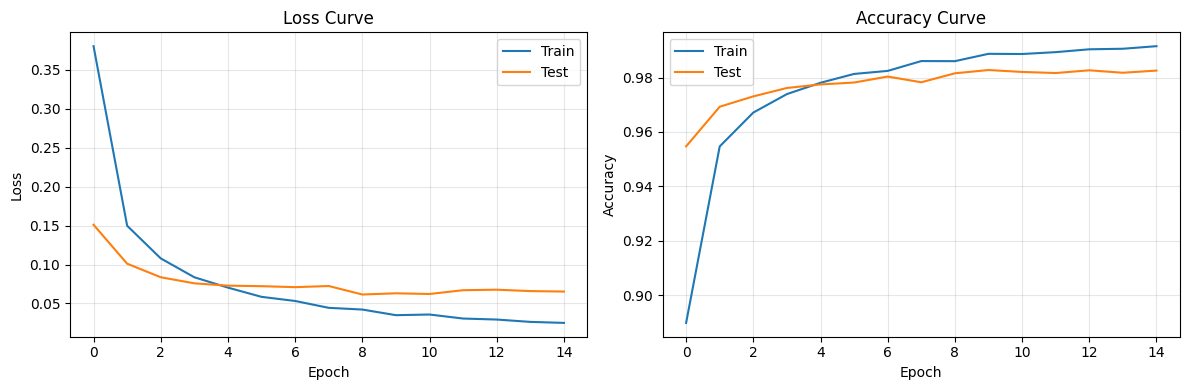

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'], label='Train')
ax1.plot(history['test_loss'], label='Test')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Curve')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history['train_acc'], label='Train')
ax2.plot(history['test_acc'], label='Test')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy Curve')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Confusion Matrix

Shows which digits get confused with each other (e.g., 4↔9, 3↔5 are common).

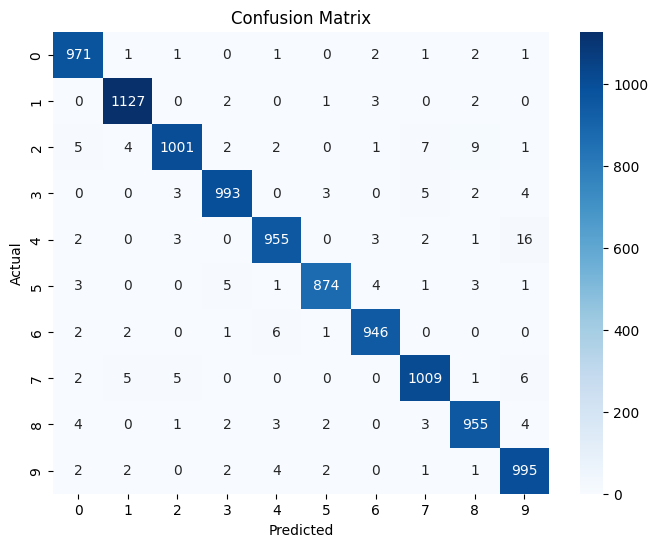

In [8]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        preds = model(X_batch.to(device)).argmax(1).cpu()
        all_preds.append(preds)
        all_labels.append(y_batch)

all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [9]:
print(classification_report(all_labels, all_preds, digits=4))

              precision    recall  f1-score   support

           0     0.9798    0.9908    0.9853       980
           1     0.9877    0.9930    0.9903      1135
           2     0.9872    0.9700    0.9785      1032
           3     0.9861    0.9832    0.9846      1010
           4     0.9825    0.9725    0.9775       982
           5     0.9898    0.9798    0.9848       892
           6     0.9864    0.9875    0.9870       958
           7     0.9806    0.9815    0.9810      1028
           8     0.9785    0.9805    0.9795       974
           9     0.9679    0.9861    0.9769      1009

    accuracy                         0.9826     10000
   macro avg     0.9827    0.9825    0.9825     10000
weighted avg     0.9826    0.9826    0.9826     10000



## 7. Misclassified Examples

Seeing what the model gets wrong helps understand its weaknesses.

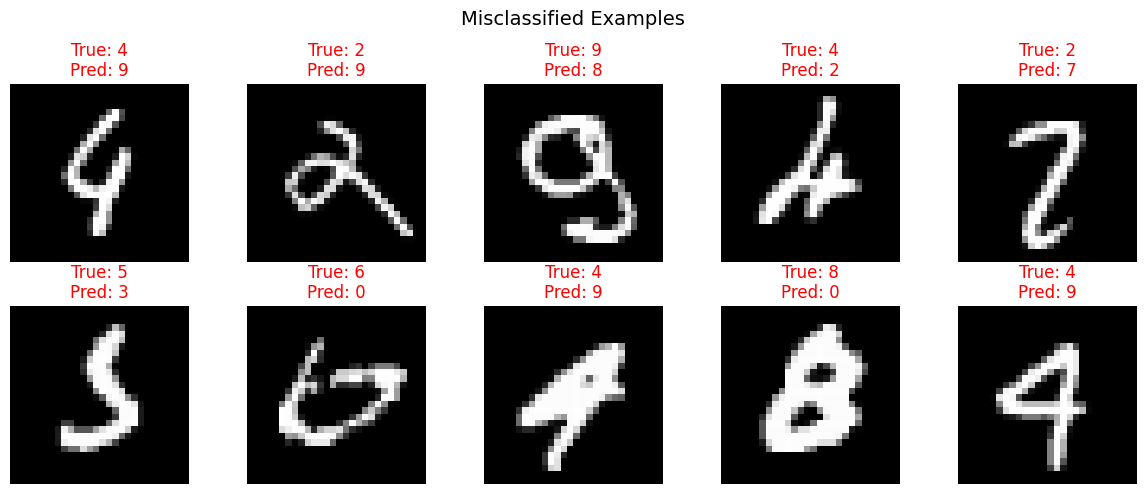

In [10]:
wrong_idx = np.where(all_preds != all_labels)[0][:10]

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, idx in enumerate(wrong_idx):
    ax = axes[i // 5, i % 5]
    ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f'True: {all_labels[idx]}\nPred: {all_preds[idx]}', color='red')
    ax.axis('off')
plt.suptitle('Misclassified Examples', fontsize=14)
plt.tight_layout()
plt.show()

## 8. Save Model & Training Results to DuckDB

In [11]:
import pandas as pd

# Save training history
history_df = pd.DataFrame(history)
history_df['epoch'] = range(1, EPOCHS + 1)

con = duckdb.connect(str(Path('../data/mnist.duckdb')))
con.execute('DROP TABLE IF EXISTS training_history')
con.execute('CREATE TABLE training_history AS SELECT * FROM history_df')
con.close()

# Save model weights
torch.save(model.state_dict(), '../data/mnist_model.pth')
print(f'Model saved. Final test accuracy: {history["test_acc"][-1]:.4f}')

Model saved. Final test accuracy: 0.9826


## 9. Experiment Ideas

Try changing these parameters and re-running to see the effect:

| Parameter | Current | Try |
|-----------|---------|-----|
| `LEARNING_RATE` | 0.001 | 0.01, 0.0001 |
| `HIDDEN1` | 256 | 64, 512 |
| `HIDDEN2` | 128 | 32, 256 |
| `DROPOUT` | 0.2 | 0.0, 0.5 |
| `EPOCHS` | 15 | 5, 30 |
| `BATCH_SIZE` | 128 | 32, 512 |
| Optimizer | Adam | SGD(lr=0.01, momentum=0.9) |